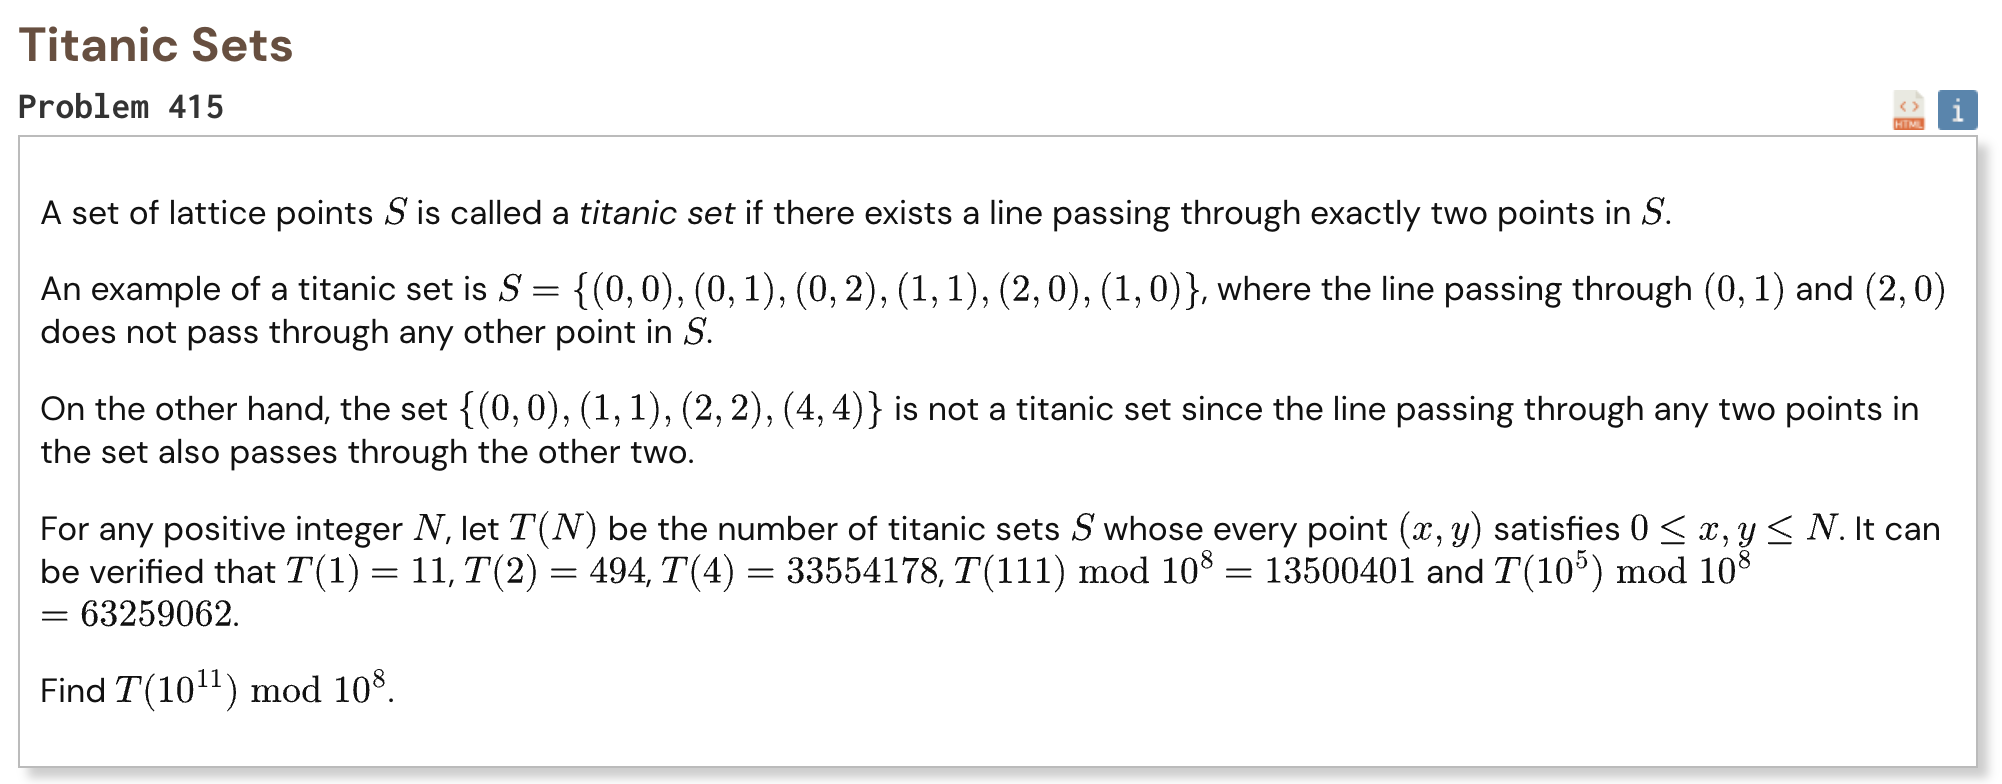

## Initial approach

-   count every possible subset of points in the square grid
-   remove the empty set and all sets containing only one point
-   a remaining set fails only when all of its selected points lie on one straight line
-   group straight lines by how many lattice points they contain
-   count primitive line directions efficiently using Euler's totient function
-   use prefix sums of totients so the enormous grid does not have to be constructed
-   process ranges where the relevant integer divisions stay unchanged
-   subtract all non-titanic collinear sets and keep only the last eight digits

In [1]:
MOD = 100_000_000
N = 10**11
LIMIT = 2_000_000


def sum1(n):
    if n <= 0:
        return 0
    return n * (n + 1) // 2 % MOD


def sum2(n):
    if n <= 0:
        return 0
    return n * (n + 1) * (2 * n + 1) // 6 % MOD


def sum3(n):
    if n <= 0:
        return 0
    x = n * (n + 1) // 2
    return x * x % MOD


def range1(a, b):
    return (sum1(b) - sum1(a - 1)) % MOD


def range2(a, b):
    return (sum2(b) - sum2(a - 1)) % MOD


def range3(a, b):
    return (sum3(b) - sum3(a - 1)) % MOD


phi = list(range(LIMIT + 1))

for p in range(2, LIMIT + 1):
    if phi[p] == p:
        for x in range(p, LIMIT + 1, p):
            phi[x] -= phi[x] // p

pref0 = [0] * (LIMIT + 1)
pref1 = [0] * (LIMIT + 1)
pref2 = [0] * (LIMIT + 1)

for i in range(1, LIMIT + 1):
    pref0[i] = (pref0[i - 1] + phi[i]) % MOD
    pref1[i] = (pref1[i - 1] + i * phi[i]) % MOD
    pref2[i] = (pref2[i - 1] + i * i * phi[i]) % MOD


cache0 = {}
cache1 = {}
cache2 = {}


def totient_sum(n):
    if n <= LIMIT:
        return pref0[n]

    if n in cache0:
        return cache0[n]

    result = sum1(n)
    left = 2

    while left <= n:
        q = n // left
        right = n // q
        result -= (right - left + 1) * totient_sum(q)
        result %= MOD
        left = right + 1

    cache0[n] = result
    return result


def weighted_totient_sum(n):
    if n <= LIMIT:
        return pref1[n]

    if n in cache1:
        return cache1[n]

    result = sum2(n)
    left = 2

    while left <= n:
        q = n // left
        right = n // q
        result -= range1(left, right) * weighted_totient_sum(q)
        result %= MOD
        left = right + 1

    cache1[n] = result
    return result


def squared_weighted_totient_sum(n):
    if n <= LIMIT:
        return pref2[n]

    if n in cache2:
        return cache2[n]

    result = sum3(n)
    left = 2

    while left <= n:
        q = n // left
        right = n // q
        result -= range2(left, right) * squared_weighted_totient_sum(q)
        result %= MOD
        left = right + 1

    cache2[n] = result
    return result


def direction_stats(n):
    if n <= 0:
        return 0, 0, 0

    count = (2 * totient_sum(n) - 1) % MOD
    coordinate_sum = (3 * weighted_totient_sum(n) - 1) % MOD
    product_sum = squared_weighted_totient_sum(n)

    return count, coordinate_sum, product_sum


def prefix_k_pow2(k):
    if k < 0:
        return 0

    power = pow(2, k + 1, MOD)
    return ((k - 1) * power + 2) % MOD


def prefix_k2_pow2(k):
    if k < 0:
        return 0

    power = pow(2, k + 1, MOD)
    return ((k * k - 2 * k + 3) * power - 6) % MOD


def solve(n):
    side = n + 1
    points = side * side

    total = pow(2, points, MOD)
    invalid = (1 + points) % MOD

    left = 2

    while left <= n:
        a = n // left
        b = n // (left + 1) if left < n else 0

        right_a = n // a
        right_b = n // b - 1 if b else n
        right = min(right_a, right_b)

        c1, s1, p1 = direction_stats(a)
        c2, s2, p2 = direction_stats(b)

        side_mod = side % MOD
        side2_mod = side_mod * side_mod % MOD

        q2 = (p1 - p2) % MOD
        q1 = (side_mod * (s2 - s1) - 2 * p2) % MOD
        q0 = (side2_mod * (c1 - c2) + side_mod * s2 - p2) % MOD

        A = 2 * q2 % MOD
        B = 2 * q1 % MOD
        C = (2 * q0 + 2 * side_mod) % MOD

        e0 = (pow(2, right + 1, MOD) - pow(2, left, MOD)) % MOD
        e1 = (prefix_k_pow2(right) - prefix_k_pow2(left - 1)) % MOD
        e2 = (prefix_k2_pow2(right) - prefix_k2_pow2(left - 1)) % MOD

        exponential = (A * e2 + B * e1 + C * e0) % MOD

        r1 = range1(left, right)
        r2 = range2(left, right)
        r3 = range3(left, right)
        length = right - left + 1

        ordinary = (
            A * (r3 + r2)
            + B * (r2 + r1)
            + C * (r1 + length)
        ) % MOD

        invalid += exponential - ordinary
        invalid %= MOD

        left = right + 1

    return (total - invalid) % MOD

```python

%%time

result = solve(N)
print("Result:", result)

```

* takes too long to run. needs an optimization.